In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pickle
import os, sys

# Root project
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added to sys.path:", project_root)



plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # Times for publication
    "font.size": 10,                    # Base font size
    "axes.labelsize": 12,              # Axis label font size
    "axes.labelweight": "bold",
    "font.weight": "bold",   
    "axes.titlesize": 13,              # Axis title (not fig title)
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 12,              # Legend font size

    "figure.dpi": 300,                 # Display resolution
    "savefig.dpi": 300,                # Save resolution
    "figure.figsize": (3.25, 2.6),     # For 0.5\textwidth plot
    "figure.constrained_layout.use": True,  # Better spacing than tight_layout

    "axes.linewidth": 0.8,             # Thin but clear axes lines
    "lines.linewidth": 1.2,
    "lines.markersize": 5,

    "axes.spines.top": False,
    "axes.spines.right": False,

    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,

    "legend.frameon": False,
    "legend.handlelength": 2.0,        # Slightly longer legend lines
    "legend.handletextpad": 0.5,

    "pdf.fonttype": 42,                # Embed editable fonts in PDF
    "ps.fonttype": 42
})



Project root added to sys.path: /Users/charithapalika/Desktop/Lab projects/Decision Making/Light_House_DBS/light_house_DBS_decision_making


In [2]:
def filter_array(input_array, indexes):
    """
    Filter array by selecting elements at specified indexes.
    
    Parameters:
    input_array : array-like
        The input array to filter
    indexes : array-like
        Indices to select from input_array
        
    Returns:
    numpy.ndarray
        Filtered array containing only elements at specified indexes
    
    Example:
    >>> arr = np.array([1,2,3,4,5])
    >>> filter_array(arr, [0,2,4])
    array([1, 3, 5])
    """
    input_array = np.array(input_array)
    indexes = np.array(indexes)
    
    if not np.all((indexes >= 0) & (indexes < len(input_array))):
        raise IndexError("Indexes out of bounds")
        
    return input_array[indexes]

# DATA

#### **PD simulations** For different del lim values
#### **STD DBS simulations** For different pulse widths and del lim values
#### **Sector DBS simulation 1** For pulse width = 20, different rot freq and del lim values
#### **Sector DBS simulation 2** For pulse width = 10, different rot freq and del lim values

In [3]:
PD_FILE_PATH = os.path.join(project_root, 'results', 'stn_gpe_system', 'data', 'PD', 'processed_data.pkl')             
STD_DBS_FILE_PATH = os.path.join(project_root, 'results', 'stn_gpe_system', 'data', 'std_DBS', 'processed_data.pkl') 
SECTOR_DBS_FILE_PATH_PW20 = os.path.join(project_root, 'results', 'stn_gpe_system', 'data', 'sector_DBS', 'processed_data_PI_20.pkl')
SECTOR_DBS_FILE_PATH_PW10 = os.path.join(project_root, 'results', 'stn_gpe_system', 'data', 'sector_DBS', 'processed_data_PI_10.pkl') 
SECTOR_DBS_FILE_PATH_PW20_LOW_FREQ = os.path.join(project_root, 'results', 'stn_gpe_system', 'data', 'sector_DBS', 'processed_data_PI_20_vlow_freq_high_amp.pkl')
SECTOR_DBS_FILE_PATH_PW10_LOW_FREQ = os.path.join(project_root, 'results', 'stn_gpe_system', 'data', 'sector_DBS', 'processed_data_PI_10_vlow_freq.pkl') 

LAT_STRENGTH_ARR = np.linspace(0.0275, 0.05, 10)

INDEXES_PLOT = np.array([0,2,4,6,8])

In [4]:
LAT_STRENGTH_ARR[INDEXES_PLOT]

array([0.0275, 0.0325, 0.0375, 0.0425, 0.0475])

In [5]:
with open(PD_FILE_PATH, 'rb') as f:
        PD_DATA = pickle.load(f)

with open(STD_DBS_FILE_PATH, 'rb') as f:
        STD_DBS_DATA = pickle.load(f)

with open(SECTOR_DBS_FILE_PATH_PW20, 'rb') as f:
        SECTOR_DBS_DATA_PW20 = pickle.load(f)

with open(SECTOR_DBS_FILE_PATH_PW10, 'rb') as f:
        SECTOR_DBS_DATA_PW10 = pickle.load(f)


with open(SECTOR_DBS_FILE_PATH_PW10_LOW_FREQ, 'rb') as f:
        SECTOR_DBS_DATA_PW10_LOW_FREQ = pickle.load(f)

with open(SECTOR_DBS_FILE_PATH_PW20_LOW_FREQ, 'rb') as f:
        SECTOR_DBS_DATA_PW20_LOW_FREQ = pickle.load(f)


PD_KEYS = list(PD_DATA['SYNC_PD'].keys())
STD_DBS_KEYS = list(STD_DBS_DATA['SYNC_STD_DBS'].keys())
SECTOR_DBS_1_KEYS = list(SECTOR_DBS_DATA_PW20['SYNC_SECTOR_DBS'].keys())
SECTOR_DBS_2_KEYS = list(SECTOR_DBS_DATA_PW10['SYNC_SECTOR_DBS'].keys())
SECTOR_DBS_3_KEYS = list(SECTOR_DBS_DATA_PW10_LOW_FREQ['SYNC_SECTOR_DBS'].keys())
SECTOR_DBS_4_KEYS = list(SECTOR_DBS_DATA_PW20_LOW_FREQ['SYNC_SECTOR_DBS'].keys())

In [6]:
# SYNC DATA
SYNC_PD = np.array([PD_DATA['SYNC_PD']['PD'][i] for i in list(PD_DATA['SYNC_PD']['PD'].keys())])

SYNC_STD_DBS_PW10 = np.array([STD_DBS_DATA['SYNC_STD_DBS']['STD_DBS_10'][i] for i in list(STD_DBS_DATA['SYNC_STD_DBS']['STD_DBS_10'].keys())])


SYNC_SECTOR_DBS_PW10_ROT5 = np.array([SECTOR_DBS_DATA_PW10['SYNC_SECTOR_DBS']['SECTOR_DBS_5'][i] for i in list(SECTOR_DBS_DATA_PW10['SYNC_SECTOR_DBS']['SECTOR_DBS_5'].keys())])
SYNC_SECTOR_DBS_PW10_ROT10 = np.array([SECTOR_DBS_DATA_PW10['SYNC_SECTOR_DBS']['SECTOR_DBS_10'][i] for i in list(SECTOR_DBS_DATA_PW10['SYNC_SECTOR_DBS']['SECTOR_DBS_5'].keys())])
SYNC_SECTOR_DBS_PW10_ROT20 = np.array([SECTOR_DBS_DATA_PW10['SYNC_SECTOR_DBS']['SECTOR_DBS_20'][i] for i in list(SECTOR_DBS_DATA_PW10['SYNC_SECTOR_DBS']['SECTOR_DBS_5'].keys())])
SYNC_SECTOR_DBS_PW10_ROT0_5 = np.array([SECTOR_DBS_DATA_PW10_LOW_FREQ['SYNC_SECTOR_DBS']['SECTOR_DBS_0_5'][i] for i in list(SECTOR_DBS_DATA_PW10_LOW_FREQ['SYNC_SECTOR_DBS']['SECTOR_DBS_0_5'].keys())])
SYNC_SECTOR_DBS_PW10_ROT1 = np.array([SECTOR_DBS_DATA_PW10_LOW_FREQ['SYNC_SECTOR_DBS']['SECTOR_DBS_1'][i] for i in list(SECTOR_DBS_DATA_PW10_LOW_FREQ['SYNC_SECTOR_DBS']['SECTOR_DBS_0_5'].keys())])
SYNC_SECTOR_DBS_PW10_ROT2 = np.array([SECTOR_DBS_DATA_PW10_LOW_FREQ['SYNC_SECTOR_DBS']['SECTOR_DBS_2'][i] for i in list(SECTOR_DBS_DATA_PW10_LOW_FREQ['SYNC_SECTOR_DBS']['SECTOR_DBS_0_5'].keys())])


SYNC_STD_DBS_PW20 = np.array([STD_DBS_DATA['SYNC_STD_DBS']['STD_DBS_20'][i] for i in list(STD_DBS_DATA['SYNC_STD_DBS']['STD_DBS_20'].keys())])
SYNC_SECTOR_DBS_PW20_ROT5 = np.array([SECTOR_DBS_DATA_PW20['SYNC_SECTOR_DBS']['SECTOR_DBS_5'][i] for i in list(SECTOR_DBS_DATA_PW20['SYNC_SECTOR_DBS']['SECTOR_DBS_5'].keys())])
SYNC_SECTOR_DBS_PW20_ROT10 = np.array([SECTOR_DBS_DATA_PW20['SYNC_SECTOR_DBS']['SECTOR_DBS_10'][i] for i in list(SECTOR_DBS_DATA_PW20['SYNC_SECTOR_DBS']['SECTOR_DBS_5'].keys())])
SYNC_SECTOR_DBS_PW20_ROT20 = np.array([SECTOR_DBS_DATA_PW20['SYNC_SECTOR_DBS']['SECTOR_DBS_20'][i] for i in list(SECTOR_DBS_DATA_PW20['SYNC_SECTOR_DBS']['SECTOR_DBS_5'].keys())])
SYNC_SECTOR_DBS_PW20_ROT0_5 = np.array([SECTOR_DBS_DATA_PW20_LOW_FREQ['SYNC_SECTOR_DBS']['SECTOR_DBS_0_5'][i] for i in list(SECTOR_DBS_DATA_PW20_LOW_FREQ['SYNC_SECTOR_DBS']['SECTOR_DBS_0_5'].keys())])
SYNC_SECTOR_DBS_PW20_ROT1 = np.array([SECTOR_DBS_DATA_PW20_LOW_FREQ['SYNC_SECTOR_DBS']['SECTOR_DBS_1'][i] for i in list(SECTOR_DBS_DATA_PW20_LOW_FREQ['SYNC_SECTOR_DBS']['SECTOR_DBS_0_5'].keys())])
SYNC_SECTOR_DBS_PW20_ROT2 = np.array([SECTOR_DBS_DATA_PW20_LOW_FREQ['SYNC_SECTOR_DBS']['SECTOR_DBS_2'][i] for i in list(SECTOR_DBS_DATA_PW20_LOW_FREQ['SYNC_SECTOR_DBS']['SECTOR_DBS_0_5'].keys())])

In [7]:
# ENTROPY DATA
ENTROPY_PD = np.array([PD_DATA['ENTROPY_PD']['PD'][i] for i in list(PD_DATA['ENTROPY_PD']['PD'].keys())])

ENTROPY_STD_DBS_PW10 = np.array([STD_DBS_DATA['ENTROPY_STD_DBS']['STD_DBS_10'][i] for i in list(STD_DBS_DATA['ENTROPY_STD_DBS']['STD_DBS_10'].keys())])

ENTROPY_SECTOR_DBS_PW10_ROT5 = np.array([SECTOR_DBS_DATA_PW10['ENTROPY_SECTOR_DBS']['SECTOR_DBS_5'][i] for i in list(SECTOR_DBS_DATA_PW10['ENTROPY_SECTOR_DBS']['SECTOR_DBS_5'].keys())])
ENTROPY_SECTOR_DBS_PW10_ROT10 = np.array([SECTOR_DBS_DATA_PW10['ENTROPY_SECTOR_DBS']['SECTOR_DBS_10'][i] for i in list(SECTOR_DBS_DATA_PW10['ENTROPY_SECTOR_DBS']['SECTOR_DBS_5'].keys())])
ENTROPY_SECTOR_DBS_PW10_ROT20 = np.array([SECTOR_DBS_DATA_PW10['ENTROPY_SECTOR_DBS']['SECTOR_DBS_20'][i] for i in list(SECTOR_DBS_DATA_PW10['ENTROPY_SECTOR_DBS']['SECTOR_DBS_5'].keys())])
ENTROPY_SECTOR_DBS_PW10_ROT0_5 = np.array([SECTOR_DBS_DATA_PW10_LOW_FREQ['ENTROPY_SECTOR_DBS']['SECTOR_DBS_0_5'][i] for i in list(SECTOR_DBS_DATA_PW10_LOW_FREQ['ENTROPY_SECTOR_DBS']['SECTOR_DBS_0_5'].keys())])
ENTROPY_SECTOR_DBS_PW10_ROT1 = np.array([SECTOR_DBS_DATA_PW10_LOW_FREQ['ENTROPY_SECTOR_DBS']['SECTOR_DBS_1'][i] for i in list(SECTOR_DBS_DATA_PW10_LOW_FREQ['ENTROPY_SECTOR_DBS']['SECTOR_DBS_0_5'].keys())])
ENTROPY_SECTOR_DBS_PW10_ROT2 = np.array([SECTOR_DBS_DATA_PW10_LOW_FREQ['ENTROPY_SECTOR_DBS']['SECTOR_DBS_2'][i] for i in list(SECTOR_DBS_DATA_PW10_LOW_FREQ['ENTROPY_SECTOR_DBS']['SECTOR_DBS_0_5'].keys())])

ENTROPY_STD_DBS_PW20 = np.array([STD_DBS_DATA['ENTROPY_STD_DBS']['STD_DBS_20'][i] for i in list(STD_DBS_DATA['ENTROPY_STD_DBS']['STD_DBS_20'].keys())])

ENTROPY_SECTOR_DBS_PW20_ROT5 = np.array([SECTOR_DBS_DATA_PW20['ENTROPY_SECTOR_DBS']['SECTOR_DBS_5'][i] for i in list(SECTOR_DBS_DATA_PW20['ENTROPY_SECTOR_DBS']['SECTOR_DBS_5'].keys())])
ENTROPY_SECTOR_DBS_PW20_ROT10 = np.array([SECTOR_DBS_DATA_PW20['ENTROPY_SECTOR_DBS']['SECTOR_DBS_10'][i] for i in list(SECTOR_DBS_DATA_PW20['ENTROPY_SECTOR_DBS']['SECTOR_DBS_5'].keys())])
ENTROPY_SECTOR_DBS_PW20_ROT20 = np.array([SECTOR_DBS_DATA_PW20['ENTROPY_SECTOR_DBS']['SECTOR_DBS_20'][i] for i in list(SECTOR_DBS_DATA_PW20['ENTROPY_SECTOR_DBS']['SECTOR_DBS_5'].keys())])
ENTROPY_SECTOR_DBS_PW20_ROT0_5 = np.array([SECTOR_DBS_DATA_PW20_LOW_FREQ['ENTROPY_SECTOR_DBS']['SECTOR_DBS_0_5'][i] for i in list(SECTOR_DBS_DATA_PW20_LOW_FREQ['ENTROPY_SECTOR_DBS']['SECTOR_DBS_0_5'].keys())])
ENTROPY_SECTOR_DBS_PW20_ROT1 = np.array([SECTOR_DBS_DATA_PW20_LOW_FREQ['ENTROPY_SECTOR_DBS']['SECTOR_DBS_1'][i] for i in list(SECTOR_DBS_DATA_PW20_LOW_FREQ['ENTROPY_SECTOR_DBS']['SECTOR_DBS_0_5'].keys())])
ENTROPY_SECTOR_DBS_PW20_ROT2 = np.array([SECTOR_DBS_DATA_PW20_LOW_FREQ['ENTROPY_SECTOR_DBS']['SECTOR_DBS_2'][i] for i in list(SECTOR_DBS_DATA_PW20_LOW_FREQ['ENTROPY_SECTOR_DBS']['SECTOR_DBS_0_5'].keys())])



In [8]:
# STD dev DATA
STD_DEV_PD = np.array([PD_DATA['STD_DEV_PD']['PD'][i].mean() for i in list(PD_DATA['STD_DEV_PD']['PD'].keys())])
STD_DEV_STD_DBS_PW10 = np.array([STD_DBS_DATA['STD_DEV_STD_DBS']['STD_DBS_10'][i].mean() for i in list(STD_DBS_DATA['STD_DEV_STD_DBS']['STD_DBS_10'].keys())])
STD_DEV_SECTOR_DBS_PW10_ROT5 = np.array([SECTOR_DBS_DATA_PW10['STD_DEV_SECTOR_DBS']['SECTOR_DBS_5'][i].mean() for i in list(SECTOR_DBS_DATA_PW10['STD_DEV_SECTOR_DBS']['SECTOR_DBS_5'].keys())])
STD_DEV_SECTOR_DBS_PW10_ROT10 = np.array([SECTOR_DBS_DATA_PW10['STD_DEV_SECTOR_DBS']['SECTOR_DBS_10'][i].mean() for i in list(SECTOR_DBS_DATA_PW10['STD_DEV_SECTOR_DBS']['SECTOR_DBS_5'].keys())])
STD_DEV_SECTOR_DBS_PW10_ROT20 = np.array([SECTOR_DBS_DATA_PW10['STD_DEV_SECTOR_DBS']['SECTOR_DBS_20'][i].mean() for i in list(SECTOR_DBS_DATA_PW10['STD_DEV_SECTOR_DBS']['SECTOR_DBS_5'].keys())])

STD_DEV_SECTOR_DBS_PW10_ROT0_5 = np.array([SECTOR_DBS_DATA_PW10_LOW_FREQ['STD_DEV_SECTOR_DBS']['SECTOR_DBS_0_5'][i].mean() for i in list(SECTOR_DBS_DATA_PW10_LOW_FREQ['STD_DEV_SECTOR_DBS']['SECTOR_DBS_0_5'].keys())])
STD_DEV_SECTOR_DBS_PW10_ROT1 = np.array([SECTOR_DBS_DATA_PW10_LOW_FREQ['STD_DEV_SECTOR_DBS']['SECTOR_DBS_1'][i].mean() for i in list(SECTOR_DBS_DATA_PW10_LOW_FREQ['STD_DEV_SECTOR_DBS']['SECTOR_DBS_0_5'].keys())])
STD_DEV_SECTOR_DBS_PW10_ROT2 = np.array([SECTOR_DBS_DATA_PW10_LOW_FREQ['STD_DEV_SECTOR_DBS']['SECTOR_DBS_2'][i].mean() for i in list(SECTOR_DBS_DATA_PW10_LOW_FREQ['STD_DEV_SECTOR_DBS']['SECTOR_DBS_0_5'].keys())])



STD_DEV_STD_DBS_PW20 = np.array([STD_DBS_DATA['STD_DEV_STD_DBS']['STD_DBS_20'][i].mean() for i in list(STD_DBS_DATA['STD_DEV_STD_DBS']['STD_DBS_20'].keys())])
STD_DEV_SECTOR_DBS_PW20_ROT5 = np.array([SECTOR_DBS_DATA_PW20['STD_DEV_SECTOR_DBS']['SECTOR_DBS_5'][i].mean() for i in list(SECTOR_DBS_DATA_PW20['STD_DEV_SECTOR_DBS']['SECTOR_DBS_5'].keys())])
STD_DEV_SECTOR_DBS_PW20_ROT10 = np.array([SECTOR_DBS_DATA_PW20['STD_DEV_SECTOR_DBS']['SECTOR_DBS_10'][i].mean() for i in list(SECTOR_DBS_DATA_PW20['STD_DEV_SECTOR_DBS']['SECTOR_DBS_5'].keys())])
STD_DEV_SECTOR_DBS_PW20_ROT20 = np.array([SECTOR_DBS_DATA_PW20['STD_DEV_SECTOR_DBS']['SECTOR_DBS_20'][i].mean() for i in list(SECTOR_DBS_DATA_PW20['STD_DEV_SECTOR_DBS']['SECTOR_DBS_5'].keys())])

STD_DEV_SECTOR_DBS_PW20_ROT0_5 = np.array([SECTOR_DBS_DATA_PW20_LOW_FREQ['STD_DEV_SECTOR_DBS']['SECTOR_DBS_0_5'][i].mean() for i in list(SECTOR_DBS_DATA_PW20_LOW_FREQ['STD_DEV_SECTOR_DBS']['SECTOR_DBS_0_5'].keys())])
STD_DEV_SECTOR_DBS_PW20_ROT1 = np.array([SECTOR_DBS_DATA_PW20_LOW_FREQ['STD_DEV_SECTOR_DBS']['SECTOR_DBS_1'][i].mean() for i in list(SECTOR_DBS_DATA_PW20_LOW_FREQ['STD_DEV_SECTOR_DBS']['SECTOR_DBS_0_5'].keys())])
STD_DEV_SECTOR_DBS_PW20_ROT2 = np.array([SECTOR_DBS_DATA_PW20_LOW_FREQ['STD_DEV_SECTOR_DBS']['SECTOR_DBS_2'][i].mean() for i in list(SECTOR_DBS_DATA_PW20_LOW_FREQ['STD_DEV_SECTOR_DBS']['SECTOR_DBS_0_5'].keys())])




In [9]:
# # STD dev processed DATA
# STD_DEV_Processed_PD = np.array([PD_DATA['STD_DEV_Processed_PD']['PD'][i].mean() for i in list(PD_DATA['STD_DEV_Processed_PD']['PD'].keys())])

# STD_DEV_Processed_STD_DBS_PW10 = np.array([STD_DBS_DATA['STD_DEV_Processed_STD_DBS']['STD_DBS_10'][i].mean() for i in list(STD_DBS_DATA['STD_DEV_Processed_STD_DBS']['STD_DBS_10'].keys())])
# STD_DEV_Processed_SECTOR_DBS_PW10_ROT5 = np.array([SECTOR_DBS_DATA_PW10['STD_DEV_Processed_SECTOR_DBS']['SECTOR_DBS_5'][i].mean() for i in list(SECTOR_DBS_DATA_PW10['STD_DEV_Processed_SECTOR_DBS']['SECTOR_DBS_5'].keys())])
# STD_DEV_Processed_SECTOR_DBS_PW10_ROT10 = np.array([SECTOR_DBS_DATA_PW10['STD_DEV_Processed_SECTOR_DBS']['SECTOR_DBS_10'][i].mean() for i in list(SECTOR_DBS_DATA_PW10['STD_DEV_Processed_SECTOR_DBS']['SECTOR_DBS_5'].keys())])
# STD_DEV_Processed_SECTOR_DBS_PW10_ROT20 = np.array([SECTOR_DBS_DATA_PW10['STD_DEV_Processed_SECTOR_DBS']['SECTOR_DBS_20'][i].mean() for i in list(SECTOR_DBS_DATA_PW10['STD_DEV_Processed_SECTOR_DBS']['SECTOR_DBS_5'].keys())])
# STD_DEV_Processed_SECTOR_DBS_PW10_ROT0_5 = np.array([SECTOR_DBS_DATA_PW10_LOW_FREQ['STD_DEV_Processed_SECTOR_DBS']['SECTOR_DBS_0_5'][i].mean() for i in list(SECTOR_DBS_DATA_PW10_LOW_FREQ['STD_DEV_Processed_SECTOR_DBS']['SECTOR_DBS_0_5'].keys())])
# STD_DEV_Processed_SECTOR_DBS_PW10_ROT1 = np.array([SECTOR_DBS_DATA_PW10_LOW_FREQ['STD_DEV_Processed_SECTOR_DBS']['SECTOR_DBS_1'][i].mean() for i in list(SECTOR_DBS_DATA_PW10_LOW_FREQ['STD_DEV_Processed_SECTOR_DBS']['SECTOR_DBS_0_5'].keys())])
# STD_DEV_Processed_SECTOR_DBS_PW10_ROT2 = np.array([SECTOR_DBS_DATA_PW10_LOW_FREQ['STD_DEV_Processed_SECTOR_DBS']['SECTOR_DBS_2'][i].mean() for i in list(SECTOR_DBS_DATA_PW10_LOW_FREQ['STD_DEV_Processed_SECTOR_DBS']['SECTOR_DBS_0_5'].keys())])



# STD_DEV_Processed_STD_DBS_PW20 = np.array([STD_DBS_DATA['STD_DEV_Processed_STD_DBS']['STD_DBS_20'][i].mean() for i in list(STD_DBS_DATA['STD_DEV_Processed_STD_DBS']['STD_DBS_20'].keys())])
# STD_DEV_Processed_SECTOR_DBS_PW20_ROT5 = np.array([SECTOR_DBS_DATA_PW20['STD_DEV_Processed_SECTOR_DBS']['SECTOR_DBS_5'][i].mean() for i in list(SECTOR_DBS_DATA_PW20['STD_DEV_Processed_SECTOR_DBS']['SECTOR_DBS_5'].keys())])
# STD_DEV_Processed_SECTOR_DBS_PW20_ROT10 = np.array([SECTOR_DBS_DATA_PW20['STD_DEV_Processed_SECTOR_DBS']['SECTOR_DBS_10'][i].mean() for i in list(SECTOR_DBS_DATA_PW20['STD_DEV_Processed_SECTOR_DBS']['SECTOR_DBS_5'].keys())])
# STD_DEV_Processed_SECTOR_DBS_PW20_ROT20 = np.array([SECTOR_DBS_DATA_PW20['STD_DEV_Processed_SECTOR_DBS']['SECTOR_DBS_20'][i].mean() for i in list(SECTOR_DBS_DATA_PW20['STD_DEV_Processed_SECTOR_DBS']['SECTOR_DBS_5'].keys())])
# STD_DEV_Processed_SECTOR_DBS_PW20_ROT0_5 = np.array([SECTOR_DBS_DATA_PW20_LOW_FREQ['STD_DEV_Processed_SECTOR_DBS']['SECTOR_DBS_0_5'][i].mean() for i in list(SECTOR_DBS_DATA_PW20_LOW_FREQ['STD_DEV_Processed_SECTOR_DBS']['SECTOR_DBS_0_5'].keys())])
# STD_DEV_Processed_SECTOR_DBS_PW20_ROT1 = np.array([SECTOR_DBS_DATA_PW20_LOW_FREQ['STD_DEV_Processed_SECTOR_DBS']['SECTOR_DBS_1'][i].mean() for i in list(SECTOR_DBS_DATA_PW20_LOW_FREQ['STD_DEV_Processed_SECTOR_DBS']['SECTOR_DBS_0_5'].keys())])
# STD_DEV_Processed_SECTOR_DBS_PW20_ROT2 = np.array([SECTOR_DBS_DATA_PW20_LOW_FREQ['STD_DEV_Processed_SECTOR_DBS']['SECTOR_DBS_2'][i].mean() for i in list(SECTOR_DBS_DATA_PW20_LOW_FREQ['STD_DEV_Processed_SECTOR_DBS']['SECTOR_DBS_0_5'].keys())])



In [10]:
# Power in beta peak 1
# ENTROPY DATA
POWER_BETA_1_PD = np.array([PD_DATA['POWER_BETA_PD_1']['PD'][i] for i in list(PD_DATA['POWER_BETA_PD_1']['PD'].keys())])

POWER_BETA_1_STD_DBS_PW10 = np.array([STD_DBS_DATA['POWER_BETA_STD_DBS_1']['STD_DBS_10'][i] for i in list(STD_DBS_DATA['POWER_BETA_STD_DBS_1']['STD_DBS_10'].keys())])
POWER_BETA_1_SECTOR_DBS_PW10_ROT5 = np.array([SECTOR_DBS_DATA_PW10['POWER_BETA_SECTOR_DBS_1']['SECTOR_DBS_5'][i] for i in list(SECTOR_DBS_DATA_PW10['POWER_BETA_SECTOR_DBS_1']['SECTOR_DBS_5'].keys())])
POWER_BETA_1_SECTOR_DBS_PW10_ROT10 = np.array([SECTOR_DBS_DATA_PW10['POWER_BETA_SECTOR_DBS_1']['SECTOR_DBS_10'][i] for i in list(SECTOR_DBS_DATA_PW10['POWER_BETA_SECTOR_DBS_1']['SECTOR_DBS_5'].keys())])
POWER_BETA_1_SECTOR_DBS_PW10_ROT20 = np.array([SECTOR_DBS_DATA_PW10['POWER_BETA_SECTOR_DBS_1']['SECTOR_DBS_20'][i] for i in list(SECTOR_DBS_DATA_PW10['POWER_BETA_SECTOR_DBS_1']['SECTOR_DBS_5'].keys())])
POWER_BETA_1_SECTOR_DBS_PW10_ROT0_5 = np.array([SECTOR_DBS_DATA_PW10_LOW_FREQ['POWER_BETA_SECTOR_DBS_1']['SECTOR_DBS_0_5'][i] for i in list(SECTOR_DBS_DATA_PW10_LOW_FREQ['POWER_BETA_SECTOR_DBS_1']['SECTOR_DBS_0_5'].keys())])
POWER_BETA_1_SECTOR_DBS_PW10_ROT1 = np.array([SECTOR_DBS_DATA_PW10_LOW_FREQ['POWER_BETA_SECTOR_DBS_1']['SECTOR_DBS_1'][i] for i in list(SECTOR_DBS_DATA_PW10_LOW_FREQ['POWER_BETA_SECTOR_DBS_1']['SECTOR_DBS_0_5'].keys())])
POWER_BETA_1_SECTOR_DBS_PW10_ROT2 = np.array([SECTOR_DBS_DATA_PW10_LOW_FREQ['POWER_BETA_SECTOR_DBS_1']['SECTOR_DBS_2'][i] for i in list(SECTOR_DBS_DATA_PW10_LOW_FREQ['POWER_BETA_SECTOR_DBS_1']['SECTOR_DBS_0_5'].keys())])


POWER_BETA_1_STD_DBS_PW20 = np.array([STD_DBS_DATA['POWER_BETA_STD_DBS_1']['STD_DBS_20'][i] for i in list(STD_DBS_DATA['POWER_BETA_STD_DBS_1']['STD_DBS_20'].keys())])
POWER_BETA_1_SECTOR_DBS_PW20_ROT5 = np.array([SECTOR_DBS_DATA_PW20['POWER_BETA_SECTOR_DBS_1']['SECTOR_DBS_5'][i] for i in list(SECTOR_DBS_DATA_PW20['POWER_BETA_SECTOR_DBS_1']['SECTOR_DBS_5'].keys())])
POWER_BETA_1_SECTOR_DBS_PW20_ROT10 = np.array([SECTOR_DBS_DATA_PW20['POWER_BETA_SECTOR_DBS_1']['SECTOR_DBS_10'][i] for i in list(SECTOR_DBS_DATA_PW20['POWER_BETA_SECTOR_DBS_1']['SECTOR_DBS_5'].keys())])
POWER_BETA_1_SECTOR_DBS_PW20_ROT20 = np.array([SECTOR_DBS_DATA_PW20['POWER_BETA_SECTOR_DBS_1']['SECTOR_DBS_20'][i] for i in list(SECTOR_DBS_DATA_PW20['POWER_BETA_SECTOR_DBS_1']['SECTOR_DBS_5'].keys())])
POWER_BETA_1_SECTOR_DBS_PW20_ROT0_5 = np.array([SECTOR_DBS_DATA_PW20_LOW_FREQ['POWER_BETA_SECTOR_DBS_1']['SECTOR_DBS_0_5'][i] for i in list(SECTOR_DBS_DATA_PW20_LOW_FREQ['POWER_BETA_SECTOR_DBS_1']['SECTOR_DBS_0_5'].keys())])
POWER_BETA_1_SECTOR_DBS_PW20_ROT1 = np.array([SECTOR_DBS_DATA_PW20_LOW_FREQ['POWER_BETA_SECTOR_DBS_1']['SECTOR_DBS_1'][i] for i in list(SECTOR_DBS_DATA_PW20_LOW_FREQ['POWER_BETA_SECTOR_DBS_1']['SECTOR_DBS_0_5'].keys())])
POWER_BETA_1_SECTOR_DBS_PW20_ROT2 = np.array([SECTOR_DBS_DATA_PW20_LOW_FREQ['POWER_BETA_SECTOR_DBS_1']['SECTOR_DBS_2'][i] for i in list(SECTOR_DBS_DATA_PW20_LOW_FREQ['POWER_BETA_SECTOR_DBS_1']['SECTOR_DBS_0_5'].keys())])


# Power in beta peak 2
POWER_BETA_2_PD = np.array([PD_DATA['POWER_BETA_PD_2']['PD'][i] for i in list(PD_DATA['POWER_BETA_PD_2']['PD'].keys())])

POWER_BETA_2_STD_DBS_PW10 = np.array([STD_DBS_DATA['POWER_BETA_STD_DBS_2']['STD_DBS_10'][i] for i in list(STD_DBS_DATA['POWER_BETA_STD_DBS_2']['STD_DBS_10'].keys())])
POWER_BETA_2_SECTOR_DBS_PW10_ROT5 = np.array([SECTOR_DBS_DATA_PW10['POWER_BETA_SECTOR_DBS_2']['SECTOR_DBS_5'][i] for i in list(SECTOR_DBS_DATA_PW10['POWER_BETA_SECTOR_DBS_2']['SECTOR_DBS_5'].keys())])
POWER_BETA_2_SECTOR_DBS_PW10_ROT10 = np.array([SECTOR_DBS_DATA_PW10['POWER_BETA_SECTOR_DBS_2']['SECTOR_DBS_10'][i] for i in list(SECTOR_DBS_DATA_PW10['POWER_BETA_SECTOR_DBS_2']['SECTOR_DBS_5'].keys())])
POWER_BETA_2_SECTOR_DBS_PW10_ROT20 = np.array([SECTOR_DBS_DATA_PW10['POWER_BETA_SECTOR_DBS_2']['SECTOR_DBS_20'][i] for i in list(SECTOR_DBS_DATA_PW10['POWER_BETA_SECTOR_DBS_2']['SECTOR_DBS_5'].keys())])
POWER_BETA_2_SECTOR_DBS_PW10_ROT0_5 = np.array([SECTOR_DBS_DATA_PW10_LOW_FREQ['POWER_BETA_SECTOR_DBS_2']['SECTOR_DBS_0_5'][i] for i in list(SECTOR_DBS_DATA_PW10_LOW_FREQ['POWER_BETA_SECTOR_DBS_2']['SECTOR_DBS_0_5'].keys())])
POWER_BETA_2_SECTOR_DBS_PW10_ROT1 = np.array([SECTOR_DBS_DATA_PW10_LOW_FREQ['POWER_BETA_SECTOR_DBS_2']['SECTOR_DBS_1'][i] for i in list(SECTOR_DBS_DATA_PW10_LOW_FREQ['POWER_BETA_SECTOR_DBS_2']['SECTOR_DBS_0_5'].keys())])
POWER_BETA_2_SECTOR_DBS_PW10_ROT2 = np.array([SECTOR_DBS_DATA_PW10_LOW_FREQ['POWER_BETA_SECTOR_DBS_2']['SECTOR_DBS_2'][i] for i in list(SECTOR_DBS_DATA_PW10_LOW_FREQ['POWER_BETA_SECTOR_DBS_2']['SECTOR_DBS_0_5'].keys())])

POWER_BETA_2_STD_DBS_PW20 = np.array([STD_DBS_DATA['POWER_BETA_STD_DBS_2']['STD_DBS_20'][i] for i in list(STD_DBS_DATA['POWER_BETA_STD_DBS_2']['STD_DBS_20'].keys())])
POWER_BETA_2_SECTOR_DBS_PW20_ROT5 = np.array([SECTOR_DBS_DATA_PW20['POWER_BETA_SECTOR_DBS_2']['SECTOR_DBS_5'][i] for i in list(SECTOR_DBS_DATA_PW20['POWER_BETA_SECTOR_DBS_2']['SECTOR_DBS_5'].keys())])
POWER_BETA_2_SECTOR_DBS_PW20_ROT10 = np.array([SECTOR_DBS_DATA_PW20['POWER_BETA_SECTOR_DBS_2']['SECTOR_DBS_10'][i] for i in list(SECTOR_DBS_DATA_PW20['POWER_BETA_SECTOR_DBS_2']['SECTOR_DBS_5'].keys())])
POWER_BETA_2_SECTOR_DBS_PW20_ROT20 = np.array([SECTOR_DBS_DATA_PW20['POWER_BETA_SECTOR_DBS_2']['SECTOR_DBS_20'][i] for i in list(SECTOR_DBS_DATA_PW20['POWER_BETA_SECTOR_DBS_2']['SECTOR_DBS_5'].keys())])
POWER_BETA_2_SECTOR_DBS_PW20_ROT0_5 = np.array([SECTOR_DBS_DATA_PW20_LOW_FREQ['POWER_BETA_SECTOR_DBS_2']['SECTOR_DBS_0_5'][i] for i in list(SECTOR_DBS_DATA_PW20_LOW_FREQ['POWER_BETA_SECTOR_DBS_2']['SECTOR_DBS_0_5'].keys())])
POWER_BETA_2_SECTOR_DBS_PW20_ROT1 = np.array([SECTOR_DBS_DATA_PW20_LOW_FREQ['POWER_BETA_SECTOR_DBS_2']['SECTOR_DBS_1'][i] for i in list(SECTOR_DBS_DATA_PW20_LOW_FREQ['POWER_BETA_SECTOR_DBS_2']['SECTOR_DBS_0_5'].keys())])
POWER_BETA_2_SECTOR_DBS_PW20_ROT2 = np.array([SECTOR_DBS_DATA_PW20_LOW_FREQ['POWER_BETA_SECTOR_DBS_2']['SECTOR_DBS_2'][i] for i in list(SECTOR_DBS_DATA_PW20_LOW_FREQ['POWER_BETA_SECTOR_DBS_2']['SECTOR_DBS_0_5'].keys())])


# Power in beta overall
POWER_BETA_PD = np.array([PD_DATA['POWER_BETA_PD']['PD'][i] for i in list(PD_DATA['POWER_BETA_PD']['PD'].keys())])

POWER_BETA_STD_DBS_PW10 = np.array([STD_DBS_DATA['POWER_BETA_STD_DBS']['STD_DBS_10'][i] for i in list(STD_DBS_DATA['POWER_BETA_STD_DBS']['STD_DBS_10'].keys())])
POWER_BETA_SECTOR_DBS_PW10_ROT5 = np.array([SECTOR_DBS_DATA_PW10['POWER_BETA_SECTOR_DBS']['SECTOR_DBS_5'][i] for i in list(SECTOR_DBS_DATA_PW10['POWER_BETA_SECTOR_DBS']['SECTOR_DBS_5'].keys())])
POWER_BETA_SECTOR_DBS_PW10_ROT10 = np.array([SECTOR_DBS_DATA_PW10['POWER_BETA_SECTOR_DBS']['SECTOR_DBS_10'][i] for i in list(SECTOR_DBS_DATA_PW10['POWER_BETA_SECTOR_DBS']['SECTOR_DBS_5'].keys())])
POWER_BETA_SECTOR_DBS_PW10_ROT20 = np.array([SECTOR_DBS_DATA_PW10['POWER_BETA_SECTOR_DBS']['SECTOR_DBS_20'][i] for i in list(SECTOR_DBS_DATA_PW10['POWER_BETA_SECTOR_DBS']['SECTOR_DBS_5'].keys())])
POWER_BETA_SECTOR_DBS_PW10_ROT0_5 = np.array([SECTOR_DBS_DATA_PW10_LOW_FREQ['POWER_BETA_SECTOR_DBS']['SECTOR_DBS_0_5'][i] for i in list(SECTOR_DBS_DATA_PW10_LOW_FREQ['POWER_BETA_SECTOR_DBS']['SECTOR_DBS_0_5'].keys())])
POWER_BETA_SECTOR_DBS_PW10_ROT1 = np.array([SECTOR_DBS_DATA_PW10_LOW_FREQ['POWER_BETA_SECTOR_DBS']['SECTOR_DBS_1'][i] for i in list(SECTOR_DBS_DATA_PW10_LOW_FREQ['POWER_BETA_SECTOR_DBS']['SECTOR_DBS_0_5'].keys())])
POWER_BETA_SECTOR_DBS_PW10_ROT2 = np.array([SECTOR_DBS_DATA_PW10_LOW_FREQ['POWER_BETA_SECTOR_DBS']['SECTOR_DBS_2'][i] for i in list(SECTOR_DBS_DATA_PW10_LOW_FREQ['POWER_BETA_SECTOR_DBS']['SECTOR_DBS_0_5'].keys())])


POWER_BETA_STD_DBS_PW20 = np.array([STD_DBS_DATA['POWER_BETA_STD_DBS']['STD_DBS_20'][i] for i in list(STD_DBS_DATA['POWER_BETA_STD_DBS']['STD_DBS_20'].keys())])
POWER_BETA_SECTOR_DBS_PW20_ROT5 = np.array([SECTOR_DBS_DATA_PW20['POWER_BETA_SECTOR_DBS']['SECTOR_DBS_5'][i] for i in list(SECTOR_DBS_DATA_PW20['POWER_BETA_SECTOR_DBS']['SECTOR_DBS_5'].keys())])
POWER_BETA_SECTOR_DBS_PW20_ROT10 = np.array([SECTOR_DBS_DATA_PW20['POWER_BETA_SECTOR_DBS']['SECTOR_DBS_10'][i] for i in list(SECTOR_DBS_DATA_PW20['POWER_BETA_SECTOR_DBS']['SECTOR_DBS_5'].keys())])
POWER_BETA_SECTOR_DBS_PW20_ROT20 = np.array([SECTOR_DBS_DATA_PW20['POWER_BETA_SECTOR_DBS']['SECTOR_DBS_20'][i] for i in list(SECTOR_DBS_DATA_PW20['POWER_BETA_SECTOR_DBS']['SECTOR_DBS_5'].keys())])
POWER_BETA_SECTOR_DBS_PW20_ROT0_5 = np.array([SECTOR_DBS_DATA_PW20_LOW_FREQ['POWER_BETA_SECTOR_DBS']['SECTOR_DBS_0_5'][i] for i in list(SECTOR_DBS_DATA_PW20_LOW_FREQ['POWER_BETA_SECTOR_DBS']['SECTOR_DBS_0_5'].keys())])
POWER_BETA_SECTOR_DBS_PW20_ROT1 = np.array([SECTOR_DBS_DATA_PW20_LOW_FREQ['POWER_BETA_SECTOR_DBS']['SECTOR_DBS_1'][i] for i in list(SECTOR_DBS_DATA_PW20_LOW_FREQ['POWER_BETA_SECTOR_DBS']['SECTOR_DBS_0_5'].keys())])
POWER_BETA_SECTOR_DBS_PW20_ROT2 = np.array([SECTOR_DBS_DATA_PW20_LOW_FREQ['POWER_BETA_SECTOR_DBS']['SECTOR_DBS_2'][i] for i in list(SECTOR_DBS_DATA_PW20_LOW_FREQ['POWER_BETA_SECTOR_DBS']['SECTOR_DBS_0_5'].keys())])


/var/folders/9v/hs9qlpdx4791kpqgpt09stch0000gn/T/ipykernel_2722/1799281497.py:110: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(wspace=0.4, hspace=1.1)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.



Beta Power (%):
εlat		STD DBS		Sector DBS
----------------------------------------
0.0275	1.0%		19.8%
0.0325	1.0%		17.9%
0.0375	0.1%		19.6%
0.0425	2.9%		17.0%
0.0475	2.7%		14.2%

Synchronization:
εlat		PD		STD DBS		Sector DBS
------------------------------------------------------------
0.0275	0.916		0.592		0.268
0.0325	0.881		0.620		0.263
0.0375	0.779		0.525		0.270
0.0425	0.895		0.628		0.275
0.0475	0.709		0.708		0.288

Standard Deviation:
εlat		PD		STD DBS		Sector DBS
------------------------------------------------------------
0.0275	0.047		0.128		0.335
0.0325	0.051		0.154		0.335
0.0375	0.077		0.132		0.335
0.0425	0.032		0.131		0.335
0.0475	0.058		0.115		0.335

Entropy:
εlat		PD		STD DBS		Sector DBS
------------------------------------------------------------
0.0275	0.308		0.340		0.727
0.0325	0.309		0.368		0.786
0.0375	0.286		0.319		0.719
0.0425	0.348		0.277		0.707
0.0475	0.301		0.299		0.744


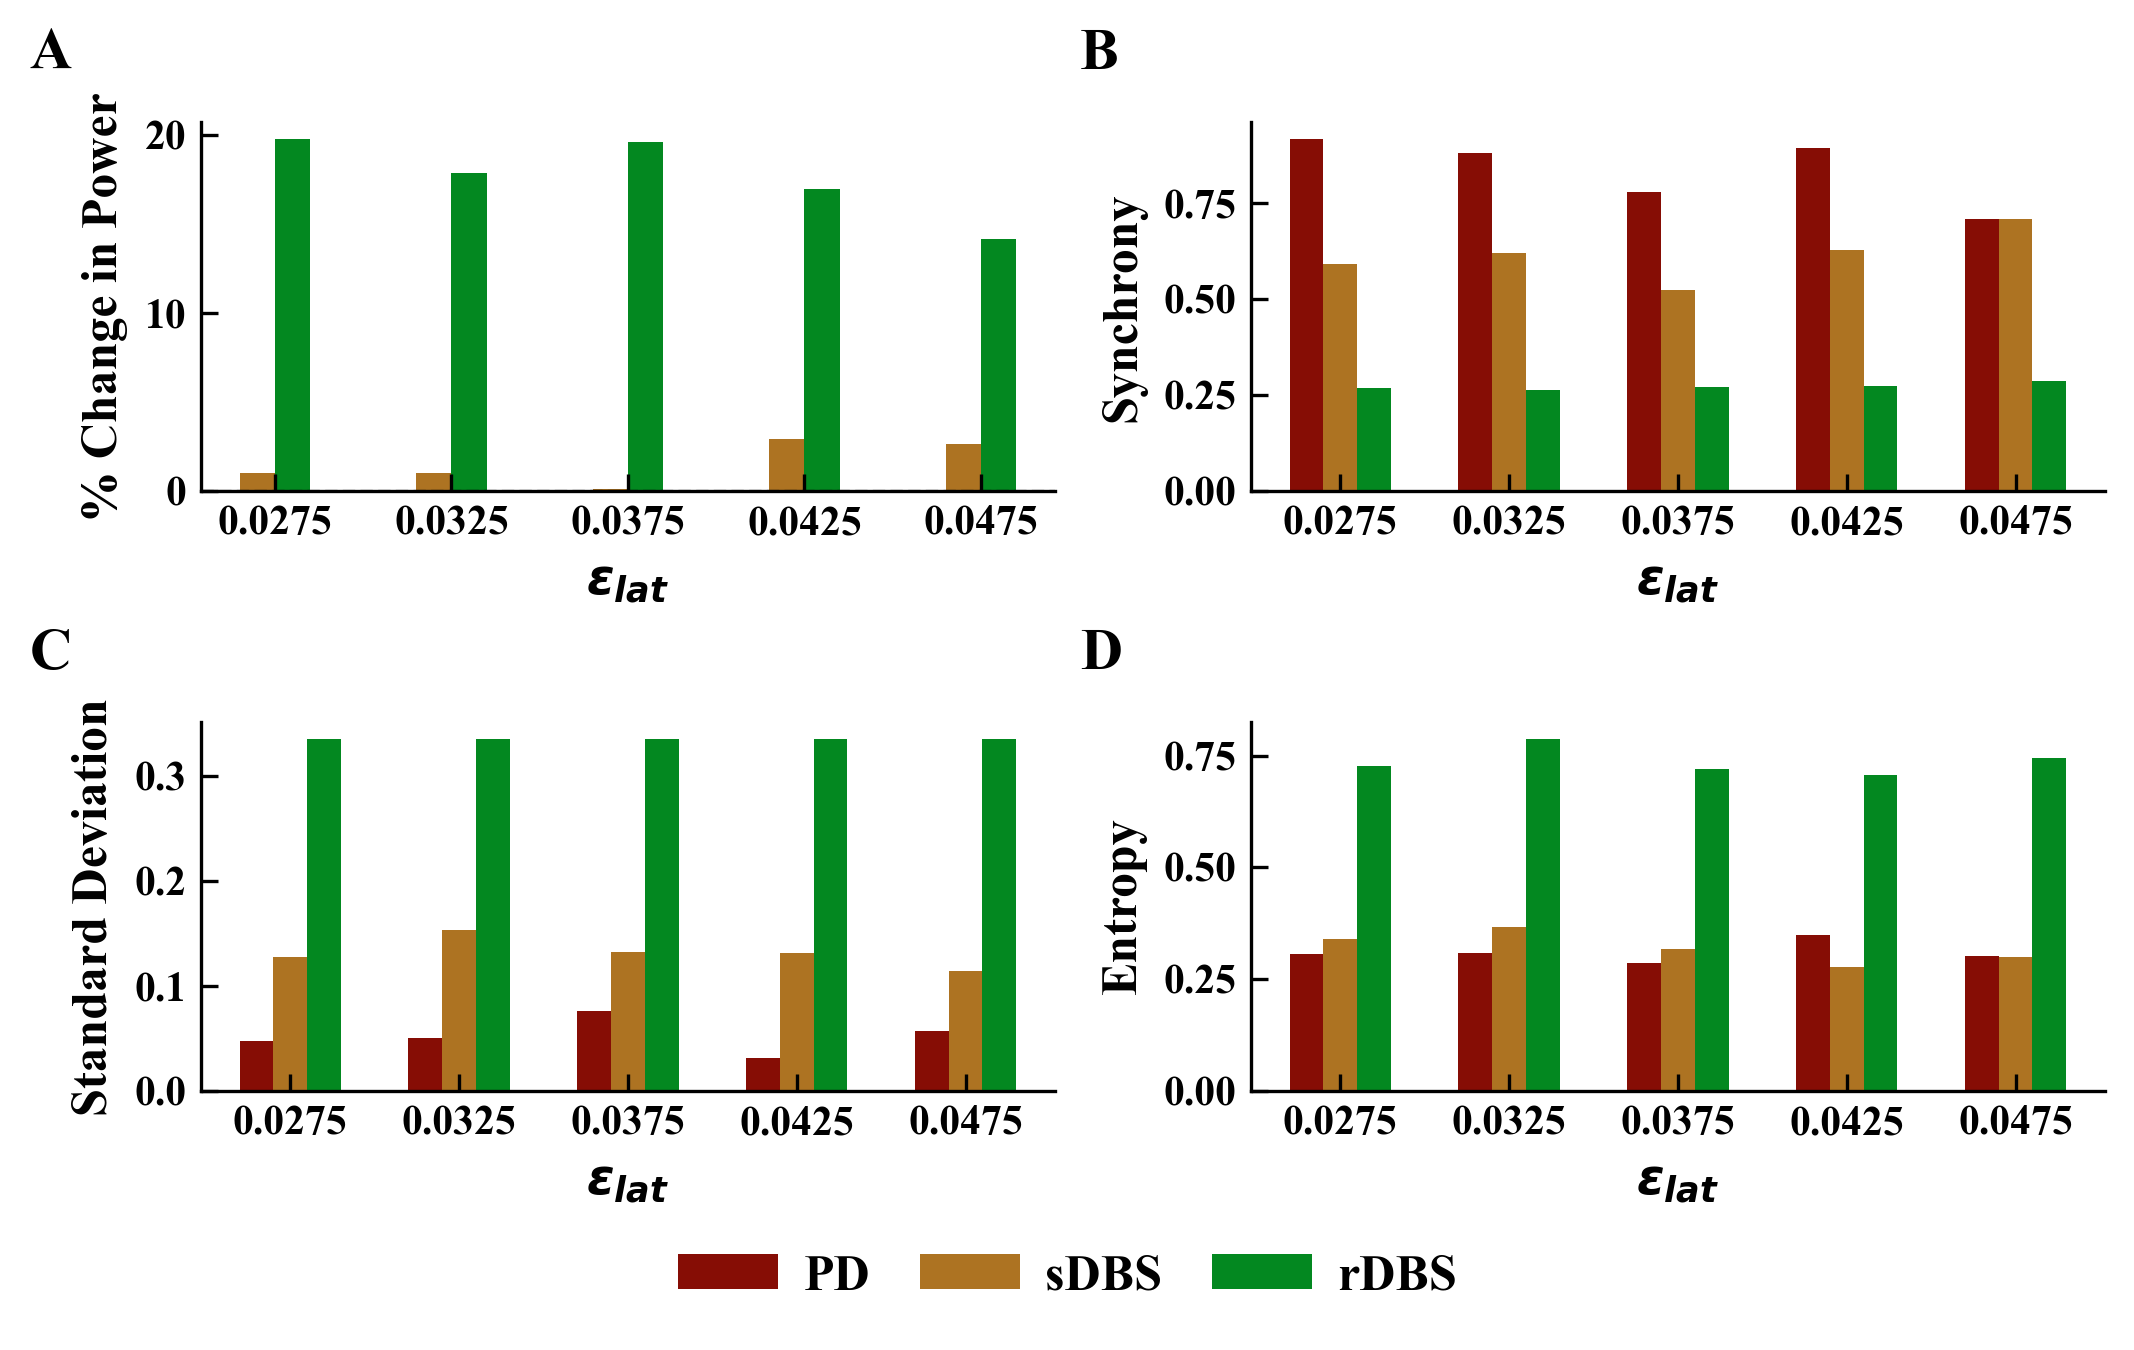

In [ ]:
# Filter arrays using INDEXES_PLOT
INDEXES_PLOT = range(0,10,2)#np.array([0,2,4,6,8])
filtered_del_lim = filter_array(LAT_STRENGTH_ARR, INDEXES_PLOT)

# Beta power data and calculate percentage change
filtered_beta_pd = filter_array(POWER_BETA_1_PD, INDEXES_PLOT)
filtered_beta_std = filter_array(POWER_BETA_1_STD_DBS_PW20, INDEXES_PLOT)
filtered_beta_sector = filter_array(POWER_BETA_1_SECTOR_DBS_PW20_ROT2, INDEXES_PLOT)

# Calculate percentage change for beta power
percent_change_std = np.abs(((filtered_beta_std - filtered_beta_pd) / filtered_beta_pd) * 100)
percent_change_sector = np.abs(((filtered_beta_sector - filtered_beta_pd) / filtered_beta_pd) * 100)

# Sync data 
filtered_sync_pd = filter_array(SYNC_PD, INDEXES_PLOT)
filtered_sync_std = filter_array(SYNC_STD_DBS_PW20, INDEXES_PLOT)
filtered_sync_sector = filter_array(SYNC_SECTOR_DBS_PW20_ROT2, INDEXES_PLOT)

# STD dev data
filtered_std_pd = filter_array(STD_DEV_PD, INDEXES_PLOT)
filtered_std_std = filter_array(STD_DEV_STD_DBS_PW20, INDEXES_PLOT)
filtered_std_sector = filter_array(STD_DEV_SECTOR_DBS_PW20_ROT2, INDEXES_PLOT)

# Entropy data
filtered_entropy_pd = filter_array(ENTROPY_PD, INDEXES_PLOT)
filtered_entropy_std = filter_array(ENTROPY_STD_DBS_PW20, INDEXES_PLOT)
filtered_entropy_sector = filter_array(ENTROPY_SECTOR_DBS_PW20_ROT2, INDEXES_PLOT)

# Create 2x2 grid plot
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(7, 4))

# Shared parameters
width = 0.2
x = np.arange(len(filtered_del_lim))
colors = {'normal':"#054b7c",
          'PD': "#860d05",
          'std_DBS': "#ad7322",
          'sector_DBS': "#038820",}

labels = ['PD', 'STD DBS', 'Sector DBS']

# Beta power percentage change plot
ax1.bar(x - width/2, percent_change_std, width, label='STD DBS', color=colors['std_DBS'])
ax1.bar(x + width/2, percent_change_sector, width, label='Sector DBS', color=colors['sector_DBS'])
ax1.axhline(y=0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
ax1.set_xlabel('$\epsilon_{lat}$')
ax1.set_ylabel('% Change in Power')
ax1.set_xticks(x)
ax1.set_xticklabels([f'{val:.4f}' for val in filtered_del_lim])
ax1.legend()

# Synchronization plot
ax2.bar(x - width, filtered_sync_pd, width, label=labels[0], color=colors['PD'])
ax2.bar(x, filtered_sync_std, width, label=labels[1], color=colors['std_DBS'])
ax2.bar(x + width, filtered_sync_sector, width, label=labels[2], color=colors['sector_DBS'])
ax2.set_xlabel('$\epsilon_{lat}$')
ax2.set_ylabel('Synchrony')
ax2.set_xticks(x)
ax2.set_xticklabels([f'{val:.4f}' for val in filtered_del_lim])
ax2.legend()

# STD dev plot
ax3.bar(x - width, filtered_std_pd, width, label=labels[0], color=colors['PD'])
ax3.bar(x, filtered_std_std, width, label=labels[1], color=colors['std_DBS'])
ax3.bar(x + width, filtered_std_sector, width, label=labels[2], color=colors['sector_DBS'])
ax3.set_xlabel('$\epsilon_{lat}$')
ax3.set_ylabel('Standard Deviation')
ax3.set_xticks(x)
ax3.set_xticklabels([f'{val:.4f}' for val in filtered_del_lim])
ax3.legend()

# Entropy plot
ax4.bar(x - width, filtered_entropy_pd, width, label=labels[0], color=colors['PD'])
ax4.bar(x, filtered_entropy_std, width, label=labels[1], color=colors['std_DBS'])
ax4.bar(x + width, filtered_entropy_sector, width, label=labels[2], color=colors['sector_DBS'])
ax4.set_xlabel('$\epsilon_{lat}$')
ax4.set_ylabel('Entropy')
ax4.set_xticks(x)
ax4.set_xticklabels([f'{val:.4f}' for val in filtered_del_lim])
ax4.legend()

for ax in [ax1, ax2, ax3, ax4]:
    ax.get_legend().remove()

legend_elements = [plt.Rectangle((0,0),0.5,0.5, facecolor=list(colors.values())[i+1]) for i in range(3)]
legend_labels = ['PD', 'sDBS', 'rDBS']

# Add the legend to the figure, centered at the bottom
fig.legend(legend_elements, legend_labels, 
          loc='center', 
          bbox_to_anchor=(0.5, -0.05), 
          ncol=3, 
          frameon=False,
          fontsize=12,
          columnspacing=1)

# Define the texts
texts = ['A', 'B', 'C', 'D']

# Define the x and y distances from the lower left corner
axs = [ax1, ax2, ax3, ax4]
x_positions = [-0.15, -0.075, -0.15, -0.075, -0.15, -0.075]

for ax, label, xpos in zip(axs, texts, x_positions):
    ax.text(-0.2, 1.25, label, transform=ax.transAxes, fontsize=14, fontweight='bold', va='top', ha='left')




plt.subplots_adjust(wspace=0.4, hspace=1.1)

# Save figs
# plt.savefig("STN_GPe_comparison.svg", format="svg",  bbox_inches="tight",pad_inches=0.05)
# plt.savefig("STN_GPe_comparison.png", format="png", bbox_inches="tight",pad_inches=0.05)
# plt.savefig("STN_GPe_comparison.pdf", format="pdf", bbox_inches="tight",pad_inches=0.05)
# plt.savefig("STN_GPe_comparison.tiff",format="tiff",dpi=600,bbox_inches="tight",pad_inches=0.05)
# plt.savefig("STN_GPe_comparison.eps",format="eps",bbox_inches="tight",pad_inches=0.05)




# Print numerical values for all metrics
metrics = ['Beta Power (%)', 'Synchronization', 'Standard Deviation', 'Entropy']
data_sets = [
    (percent_change_std, percent_change_sector),
    (filtered_sync_pd, filtered_sync_std, filtered_sync_sector),
    (filtered_std_pd, filtered_std_std, filtered_std_sector),
    (filtered_entropy_pd, filtered_entropy_std, filtered_entropy_sector)
]

for metric, data in zip(metrics, data_sets):
    print(f"\n{metric}:")
    if metric == 'Beta Power (%)':
        print("εlat\t\tSTD DBS\t\tSector DBS")
        print("-"*40)
        for i in range(len(filtered_del_lim)):
            print(f"{filtered_del_lim[i]:.4f}\t{data[0][i]:.1f}%\t\t{data[1][i]:.1f}%")
    else:
        print("εlat\t\tPD\t\tSTD DBS\t\tSector DBS")
        print("-"*60)
        for i in range(len(filtered_del_lim)):
            print(f"{filtered_del_lim[i]:.4f}\t{data[0][i]:.3f}\t\t{data[1][i]:.3f}\t\t{data[2][i]:.3f}")